In [1]:
import pandas as pd
import os

In [2]:
os.chdir(r"J:\BLA_three_types\percent")

In [3]:
os.listdir()

['BLA_3_cluster5.xlsx']

In [4]:
df = pd.read_excel("BLA_3_cluster5.xlsx",index_col=0)

In [11]:
df["geno"] = [item.split("_")[-1] for item in df.index.tolist()]

In [13]:
pct_df

Type,1,2,3,4,5
geno,,,,,
Sst,38.888889,38.888889,22.222222,0.0,0.0
Crh,20.000000,0.000000,80.000000,0.0,0.0
Vglut1,0.000000,0.000000,10.000000,20.0,70.0


In [24]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rc("font",family="Arial")

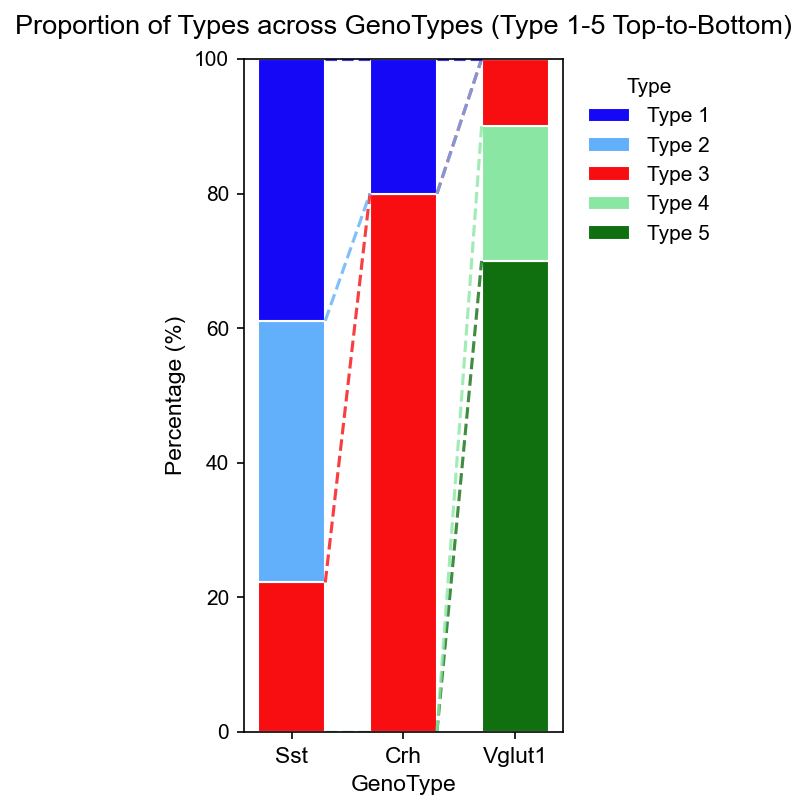

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re


# df = pd.DataFrame(matches, columns=['file', 'Type', 'geno'])

geno_order = ['Sst', 'Crh', 'Vglut1']
all_Types = sorted(df['Type'].unique(), key=lambda x: int(x))
pct_df = (pd.crosstab(df['geno'], df['Type'], normalize='index') * 100).reindex(index=geno_order, columns=all_Types, fill_value=0)

# If Type 1-5 from top to bottom:
# Top is Type 1, then Type 2, Type 3, Type 4, Type 5 (bottom).
# When stacking from bottom (y=0) up to 100: stack order should be Type 5, Type 4, Type 3, Type 2, Type 1.
# Or draw from top: y=100 down. In matplotlib, bottom-up stacking order is Types[::-1], i.e., ['5', '4', '3', '2', '1'].

# Custom color palette interface
custom_colors = {
    1: "#1408f7",
    2: "#62affc",
    3: "#f80d11",
    4: "#8ae7a3",
    5: '#107010'
}

stack_order = [5, 4, 3, 2, 1]

fig, ax = plt.subplots(figsize=(4, 5.5), dpi=150)

bar_width = 0.6
x_pos = np.arange(len(geno_order))
bottom = np.zeros(len(geno_order))

for t in stack_order:
    values = pct_df[t].values
    col = custom_colors.get(t, '#cccccc')
    
    bars = ax.bar(x_pos, values, bottom=bottom, width=bar_width,
                  label=f'Type {t}', color=col, edgecolor='white', linewidth=1)
    
    top_prev = bottom + values
    for g_idx in range(len(geno_order) - 1):
        x_left = x_pos[g_idx] + bar_width / 2
        x_right = x_pos[g_idx + 1] - bar_width / 2
        ax.plot([x_left, x_right], [top_prev[g_idx], top_prev[g_idx + 1]],
                color=col, linestyle='--', linewidth=1.5, alpha=0.8)
    
    bottom += values

ax.set_xticks(x_pos)
ax.set_xticklabels(geno_order, fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xlabel('GenoType', fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Proportion of Types across GenoTypes (Type 1-5 Top-to-Bottom)', fontsize=13, pad=12)

# Legend matching the visual order (Type 1 on top -> Type 5 at bottom)
handles, labels = ax.get_legend_handles_labels()
# Since we drew 5, 4, 3, 2, 1, reversing handles gives 1, 2, 3, 4, 5
ax.legend(handles[::-1], labels[::-1], title='Type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('stacked_bar_custom.png')
plt.savefig('stacked_bar_custom.pdf')
# plt.close()

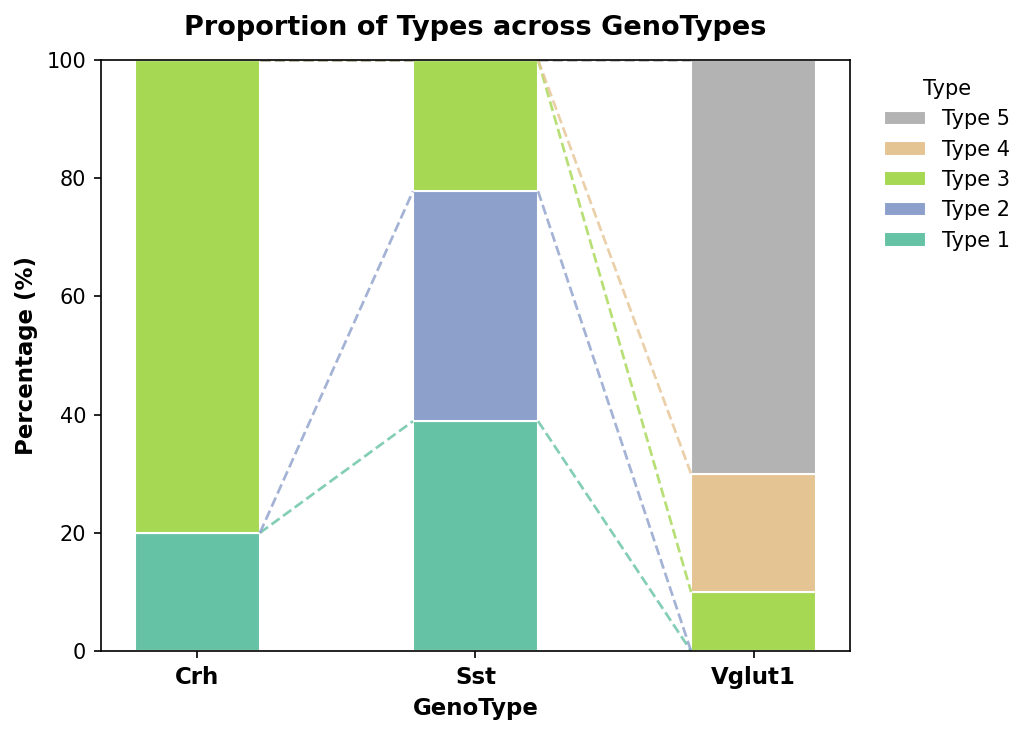

In [9]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



# 2. 计算各 geno 内 Type 的百分比
geno_order = ["Crh", "Sst", "Vglut1"]
Types = sorted(df["Type"].unique(), key=lambda x: int(x))
pct_df = (
    pd.crosstab(df["geno"], df["Type"], normalize="index") * 100
).reindex(index=geno_order, columns=Types, fill_value=0)

# 3. 绘制堆叠柱状图及跨组虚线
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

bar_width = 0.45
x_pos = np.arange(len(geno_order))
bottom = np.zeros(len(geno_order))
colors = plt.cm.Set2(np.linspace(0, 1, len(Types)))

for i, t in enumerate(Types):
  values = pct_df[t].values
  # 绘制柱状堆叠块
  bars = ax.bar(
      x_pos,
      values,
      bottom=bottom,
      width=bar_width,
      label=f"Type {t}",
      color=colors[i],
      edgecolor="white",
      linewidth=1,
  )

  # 计算每个分块的顶部位置并绘制相邻基因型间的连接虚线
  top_prev = bottom + values
  for g_idx in range(len(geno_order) - 1):
    x_left = x_pos[g_idx] + bar_width / 2
    x_right = x_pos[g_idx + 1] - bar_width / 2
    ax.plot(
        [x_left, x_right],
        [top_prev[g_idx], top_prev[g_idx + 1]],
        color=colors[i],
        linestyle="--",
        linewidth=1.3,
        alpha=0.8,
    )

  bottom += values

# 4. 图表美化与修饰
ax.set_xticks(x_pos)
ax.set_xticklabels(geno_order, fontsize=11, fontweight="bold")
ax.set_ylabel("Percentage (%)", fontsize=11, fontweight="bold")
ax.set_xlabel("GenoType", fontsize=11, fontweight="bold")
ax.set_ylim(0, 100)
ax.set_title(
    "Proportion of Types across GenoTypes",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

# 调整图例顺序（自上而下匹配堆叠层级）
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

plt.tight_layout()
plt.show()